In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,MinMaxScaler
from sklearn.metrics import accuracy_score,classification_report, confusion_matrix,precision_score, recall_score, f1_score,roc_auc_score
from imblearn.over_sampling import SMOTE
from tensorflow.keras.models import load_model
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.naive_bayes import GaussianNB


In [2]:
data_train=pd.read_csv('KDDTrain+.txt', header=None)
data_test=pd.read_csv('KDDTest+.txt', header=None)

In [3]:
columns = (['duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment','urgent','hot'
,'num_failed_logins','logged_in','num_compromised','root_shell','su_attempted','num_root','num_file_creations'
,'num_shells','num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count','srv_count','serror_rate'
,'srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate','dst_host_count','dst_host_srv_count'
,'dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate'
,'dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate','outcome','level'])
data_train.columns = columns
data_test.columns = columns

In [4]:
data_train.drop("level", axis=1, inplace=True)
data_test.drop("level", axis=1, inplace=True)

In [5]:
attack_mapping = {
    'normal': 'normal',
    'neptune': 'DoS',
    'smurf': 'DoS',
    'back': 'DoS',
    'teardrop': 'DoS',
    'pod': 'DoS',
    'land': 'DoS',
    'apache2': 'DoS',
    'mailbomb': 'DoS',
    'processtable': 'DoS',
    'udpstorm': 'DoS',
    'nuked': 'DoS',
    'worm': 'DoS',

    'ipsweep': 'Probe',
    'portsweep': 'Probe',
    'nmap': 'Probe',
    'satan': 'Probe',
    'mscan': 'Probe',
    'saint': 'Probe',
    'xsnoop': 'Probe',
    'snmpgetattack': 'Probe',
    'snmpguess': 'Probe',
    'httptunnel': 'Probe',

    'warezclient': 'R2L',
    'guess_passwd': 'R2L',
    'ftp_write': 'R2L',
    'multihop': 'R2L',
    'imap': 'R2L',
    'warezmaster': 'R2L',
    'phf': 'R2L',
    'spy': 'R2L',
    'sendmail': 'R2L',
    'secrect': 'R2L',

    'rootkit': 'U2R',
    'buffer_overflow': 'U2R',
    'loadmodule': 'U2R',
    'perl': 'U2R',
    'ps': 'U2R',
    'sqlattack': 'U2R',
    'xterm': 'U2R',
    'named': 'U2R',
    'xlock': 'U2R'
}

unmapped_attacks = set(data_train['outcome'].unique()) - set(attack_mapping.keys())
if unmapped_attacks:
    print(f"Warning: The following attack types in 'outcome' are not in the provided mapping: {unmapped_attacks}. They will be mapped to 'Other_Attack'.")
    for attack in unmapped_attacks:
        attack_mapping[attack] = 'Other_Attack'

data_train['attack_class'] = data_train['outcome'].map(attack_mapping)
data_test['attack_class'] = data_test['outcome'].map(attack_mapping)

print("\nValue counts for 'attack_class' after mapping:")
print(data_train['attack_class'].value_counts())
print("\nValue counts for 'attack_class' in test set after mapping:")
print(data_test['attack_class'].value_counts())


Value counts for 'attack_class' after mapping:
attack_class
normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64

Value counts for 'attack_class' in test set after mapping:
attack_class
normal    9711
DoS       7460
Probe     3067
R2L       2213
U2R         93
Name: count, dtype: int64


In [6]:
data_train = pd.get_dummies(
    data_train,
    columns=['protocol_type', 'service', 'flag'],
    drop_first=True
)
data_test = pd.get_dummies(
    data_test,
    columns=['protocol_type', 'service', 'flag'],
    drop_first=True
)

In [7]:
data_train, data_test = data_train.align(
    data_test,
    join='left',
    axis=1,
    fill_value=0
)

In [8]:
le=LabelEncoder()
data_train['attack_class'] = le.fit_transform(data_train['attack_class'])
data_test['attack_class'] = le.transform(data_test['attack_class'])

In [9]:
X_train = data_train.drop(['attack_class', 'outcome'], axis=1)
y_train = data_train['attack_class']
X_test = data_test.drop(['attack_class', 'outcome'], axis=1)
y_test = data_test['attack_class']

### Feature Scaling and Model Training

Now, I will apply `StandardScaler` to the numerical features. After scaling, I will train and evaluate several linear models: Logistic Regression, K-Nearest Neighbors, Support Vector Machine, and Naive Bayes.

In [11]:
import numpy as np # Ensure np is defined

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Define X_train, y_train, X_test, y_test (from VcXAfaAg-hCT)
X_train = data_train.drop(['attack_class', 'outcome'], axis=1)
y_train = data_train['attack_class']
X_test = data_test.drop(['attack_class', 'outcome'], axis=1)
y_test = data_test['attack_class']

# Identify numerical columns for scaling
numerical_cols = X_train.select_dtypes(include=np.number).columns

# Initialize StandardScaler
scaler = StandardScaler()

# Fit on training data and transform both training and test data
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("Numerical features scaled successfully.")

# Display the first few rows of the scaled training data
display(X_train_scaled.head())

Numerical features scaled successfully.


,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,protocol_type_tcp,protocol_type_udp,...,service_netstat,service_nnsp,service_nntp,service_ntp_u,service_other,service_pm_dump,service_pop_2,service_pop_3,service_printer,service_private,service_red_i,service_remote_job,service_rje,service_shell,service_smtp,service_sql_net,service_ssh,service_sunrpc,service_supdup,service_systat,service_telnet,service_tftp_u,service_tim_i,service_time,service_urh_i,service_urp_i,service_uucp,service_uucp_path,service_vmnet,service_whois,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,-0.110249,-0.007679,-0.004919,-0.014089,-0.089486,-0.007736,-0.095076,-0.027023,-0.809262,-0.011664,-0.036652,-0.024437,-0.012385,-0.02618,-0.01861,-0.041221,0.0,-0.002817,-0.097531,-0.717045,-0.354343,-0.637209,-0.631929,-0.374362,-0.374432,0.771283,-0.349683,-0.374560,-0.324063,-0.818890,-0.782367,-0.280282,0.069972,-0.289103,-0.639532,-0.624871,-0.224532,-0.376387,True,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
1,-0.110249,-0.007737,-0.004919,-0.014089,-0.089486,-0.007736,-0.095076,-0.027023,-0.809262,-0.011664,-0.036652,-0.024437,-0.012385,-0.02618,-0.01861,-0.041221,0.0,-0.002817,-0.097531,-0.620982,-0.368110,-0.637209,-0.631929,-0.374362,-0.374432,-1.321428,0.482201,-0.374560,0.734343,-1.035688,-1.161030,2.736852,2.367737,-0.289103,-0.639532,-0.624871,-0.387635,-0.376387,False,True,...,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
2,-0.110249,-0.007762,-0.004919,-0.014089,-0.089486,-0.007736,-0.095076,-0.027023,-0.809262,-0.011664,-0.036652,-0.024437,-0.012385,-0.02618,-0.01861,-0.041221,0.0,-0.002817,-0.097531,0.339648,-0.299273,1.602664,1.605104,-0.374362,-0.374432,-1.389669,0.038529,-0.374560,0.734343,-0.809857,-0.938287,-0.174417,-0.480197,-0.289103,1.608759,1.618955,-0.387635,-0.376387,True,False,...,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
3,-0.110249,-0.007723,-0.002891,-0.014089,-0.089486,-0.007736,-0.095076,-0.027023,1.235694,-0.011664,-0.036652,-0.024437,-0.012385,-0.02618,-0.01861,-0.041221,0.0,-0.002817,-0.097531,-0.690846,-0.313041,-0.189235,-0.184522,-0.374362,-0.374432,0.771283,-0.349683,-0.374560,-1.533670,1.258754,1.066401,-0.439078,-0.383108,0.066252,-0.572083,-0.602433,-0.387635,-0.345084,True,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
4,-0.110249,-0.007728,-0.004814,-0.014089,-0.089486,-0.007736,-0.095076,-0.027023,1.235694,-0.011664,-0.036652,-0.024437,-0.012385,-0.02618,-0.01861,-0.041221,0.0,-0.002817,-0.097531,-0.472521,0.058678,-0.637209,-0.631929,-0.374362,-0.374432,0.771283,-0.349683,-0.028179,0.734343,1.258754,1.066401,-0.439078,-0.480197,-0.289103,-0.639532,-0.624871,-0.387635,-0.3763

In [12]:
smote = SMOTE(

    sampling_strategy={
        2: 5000,
        3: 1500
    },

    random_state=42,
    k_neighbors=3
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

In [12]:
# This cell previously contained problematic reassignments that corrupted the test set.
# It has been emptied to prevent further issues.
# Ensure X_test_scaled is correctly generated by re-running the scaling cell (3b606ab3).

### Logistic Regression

Logistic Regression Performance:
Accuracy: 0.7633
Precision: 0.7940
Recall: 0.7633
F1 Score: 0.7406

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.81      0.86      7460
           1       0.87      0.58      0.70      3067
           2       0.82      0.14      0.24      2213
           3       0.30      0.23      0.26        93
           4       0.67      0.93      0.78      9711

    accuracy                           0.76     22544
   macro avg       0.72      0.54      0.57     22544
weighted avg       0.79      0.76      0.74     22544



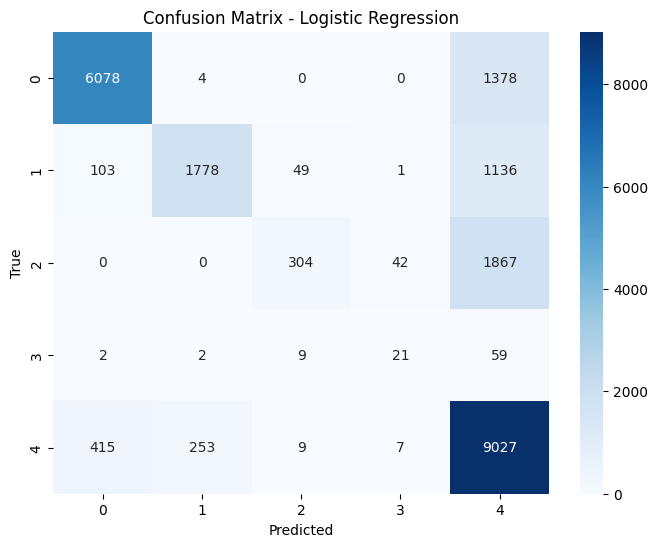

In [13]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_smote, y_train_smote)

y_pred_lr = log_reg.predict(X_test_scaled)

print("Logistic Regression Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_lr, average='weighted'):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_lr, average='weighted'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

### K-Nearest Neighbors (KNN)

K-Nearest Neighbors Performance:
Accuracy: 0.7689
Precision: 0.8120
Recall: 0.7689
F1 Score: 0.7355

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.82      0.88      7460
           1       0.84      0.54      0.66      3067
           2       0.89      0.05      0.10      2213
           3       0.61      0.29      0.39        93
           4       0.67      0.97      0.79      9711

    accuracy                           0.77     22544
   macro avg       0.80      0.53      0.57     22544
weighted avg       0.81      0.77      0.74     22544



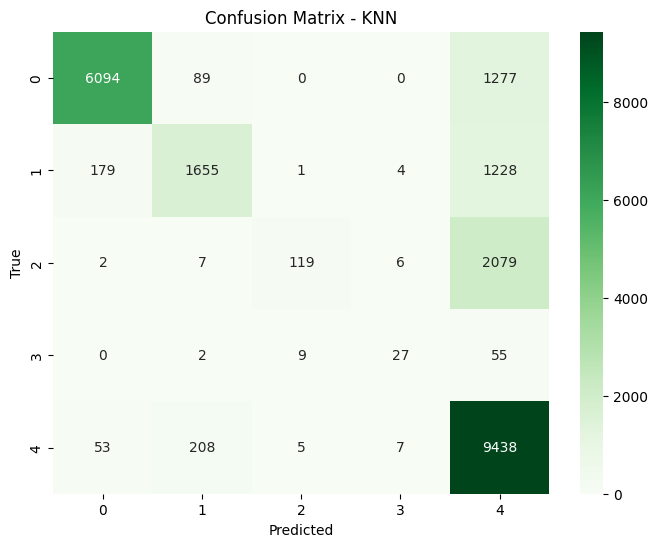

In [14]:
knn = KNeighborsClassifier(n_neighbors=5) # Using 5 neighbors as a common starting point
knn.fit(X_train_smote, y_train_smote)

y_pred_knn = knn.predict(X_test_scaled)

print("K-Nearest Neighbors Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_knn, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_knn, average='weighted'):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_knn, average='weighted'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

cm_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - KNN')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

### Support Vector Machine (SVM)

Support Vector Machine Performance:
Accuracy: 0.7556
Precision: 0.8117
Recall: 0.7556
F1 Score: 0.7310

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.77      0.85      7460
           1       0.84      0.51      0.63      3067
           2       0.96      0.14      0.25      2213
           3       0.62      0.14      0.23        93
           4       0.65      0.97      0.78      9711

    accuracy                           0.76     22544
   macro avg       0.81      0.51      0.55     22544
weighted avg       0.81      0.76      0.73     22544



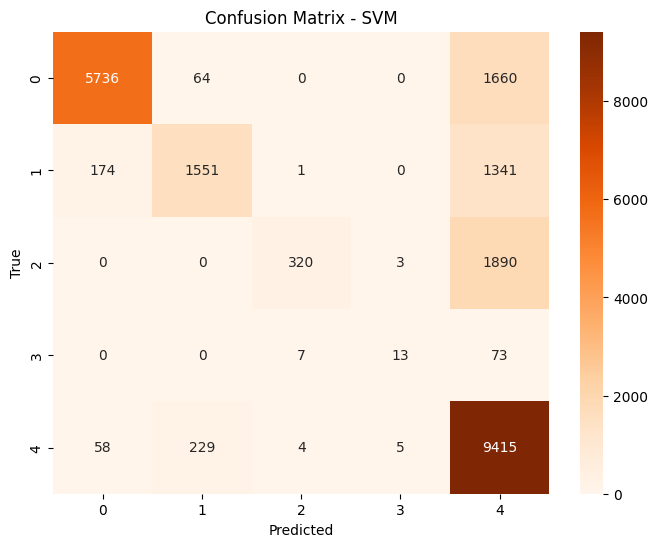

In [15]:
svm = SVC(random_state=42)
svm.fit(X_train_smote, y_train_smote)

y_pred_svm = svm.predict(X_test_scaled)

print("Support Vector Machine Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_svm, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_svm, average='weighted'):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_svm, average='weighted'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Oranges')
plt.title('Confusion Matrix - SVM')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

### Naive Bayes (GaussianNB)

Naive Bayes (GaussianNB) Performance:
Accuracy: 0.4951
Precision: 0.6666
Recall: 0.4951
F1 Score: 0.5063

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.48      0.62      7460
           1       0.91      0.10      0.17      3067
           2       0.18      0.46      0.26      2213
           3       0.05      0.52      0.10        93
           4       0.53      0.64      0.58      9711

    accuracy                           0.50     22544
   macro avg       0.51      0.44      0.35     22544
weighted avg       0.67      0.50      0.51     22544



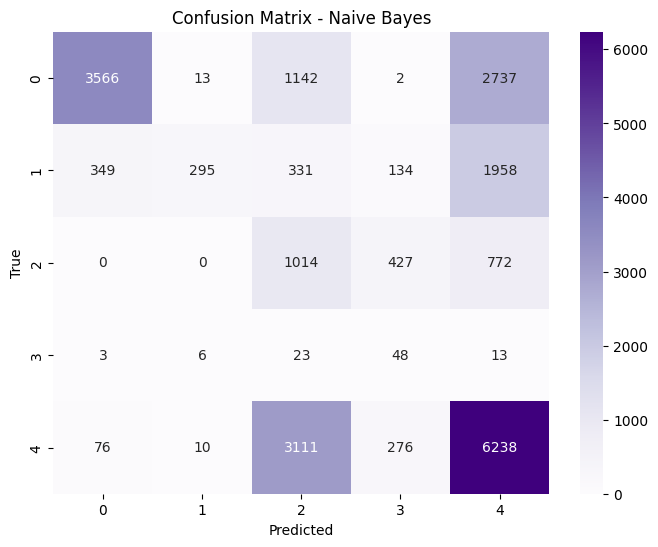

In [16]:
gnb = GaussianNB()
gnb.fit(X_train_smote, y_train_smote)

y_pred_gnb = gnb.predict(X_test_scaled)

print("Naive Bayes (GaussianNB) Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_gnb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_gnb, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_gnb, average='weighted'):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_gnb, average='weighted'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gnb))

cm_gnb = confusion_matrix(y_test, y_pred_gnb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_gnb, annot=True, fmt='d', cmap='Purples')
plt.title('Confusion Matrix - Naive Bayes')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

### Save Trained Models

I will now save the trained models using `joblib` for future use.

In [17]:
import joblib

joblib.dump(log_reg, 'logistic_regression_model.pkl')
print("Logistic Regression model saved as 'logistic_regression_model.pkl'")

joblib.dump(knn, 'knn_model.pkl')
print("KNN model saved as 'knn_model.pkl'")

joblib.dump(svm, 'svm_model.pkl')
print("SVM model saved as 'svm_model.pkl'")

joblib.dump(gnb, 'naive_bayes_model.pkl')
print("Naive Bayes model saved as 'naive_bayes_model.pkl'")

joblib.dump(scaler, 'standard_scaler.pkl')
print("StandardScaler saved as 'standard_scaler.pkl'")


Logistic Regression model saved as 'logistic_regression_model.pkl'
KNN model saved as 'knn_model.pkl'
SVM model saved as 'svm_model.pkl'
Naive Bayes model saved as 'naive_bayes_model.pkl'
StandardScaler saved as 'standard_scaler.pkl'


## With Power Transformer

In [17]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')

X_train_pt = pt.fit_transform(X_train_smote)
X_test_pt = pt.transform(X_test_scaled)

Logistic Regression Performance:
Accuracy: 0.7674
Precision: 0.7944
Recall: 0.7674
F1 Score: 0.7564

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.79      0.87      7460
           1       0.72      0.60      0.66      3067
           2       0.80      0.25      0.38      2213
           3       0.11      0.35      0.17        93
           4       0.70      0.92      0.80      9711

    accuracy                           0.77     22544
   macro avg       0.66      0.58      0.57     22544
weighted avg       0.79      0.77      0.76     22544



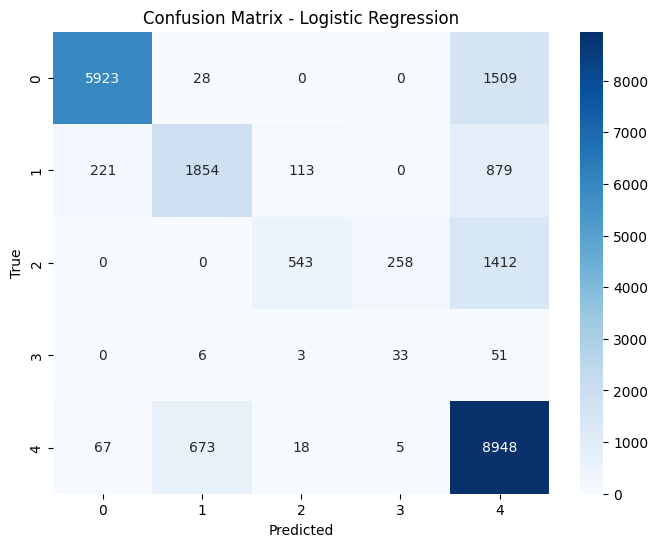

In [18]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_pt, y_train_smote)

y_pred_lr = log_reg.predict(X_test_pt)

print("Logistic Regression Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_lr, average='weighted'):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_lr, average='weighted'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

K-Nearest Neighbors Performance:
Accuracy: 0.7557
Precision: 0.7927
Recall: 0.7557
F1 Score: 0.7465

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.76      0.83      7460
           1       0.68      0.56      0.61      3067
           2       0.98      0.29      0.45      2213
           3       0.09      0.39      0.15        93
           4       0.71      0.92      0.80      9711

    accuracy                           0.76     22544
   macro avg       0.67      0.58      0.57     22544
weighted avg       0.79      0.76      0.75     22544



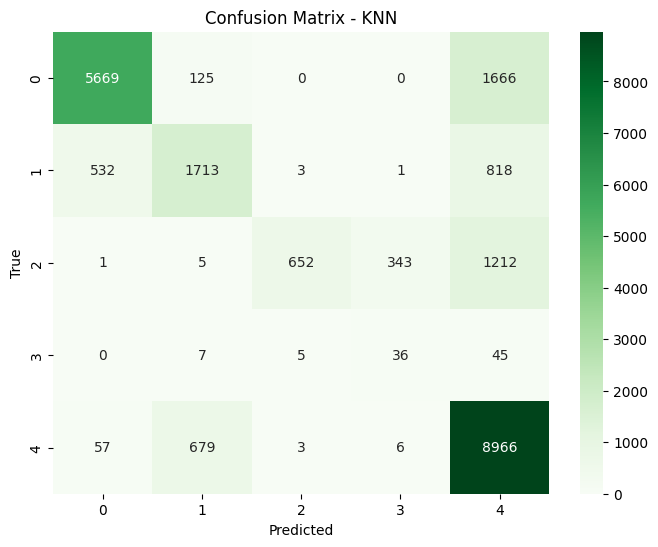

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5) 
knn.fit(X_train_pt, y_train_smote)

y_pred_knn = knn.predict(X_test_pt)

print("K-Nearest Neighbors Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_knn, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_knn, average='weighted'):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_knn, average='weighted'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

cm_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - KNN')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

Support Vector Machine Performance:
Accuracy: 0.7800
Precision: 0.8130
Recall: 0.7800
F1 Score: 0.7648

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.85      0.89      7460
           1       0.71      0.58      0.64      3067
           2       0.98      0.20      0.34      2213
           3       0.05      0.20      0.08        93
           4       0.73      0.92      0.81      9711

    accuracy                           0.78     22544
   macro avg       0.68      0.55      0.55     22544
weighted avg       0.81      0.78      0.76     22544



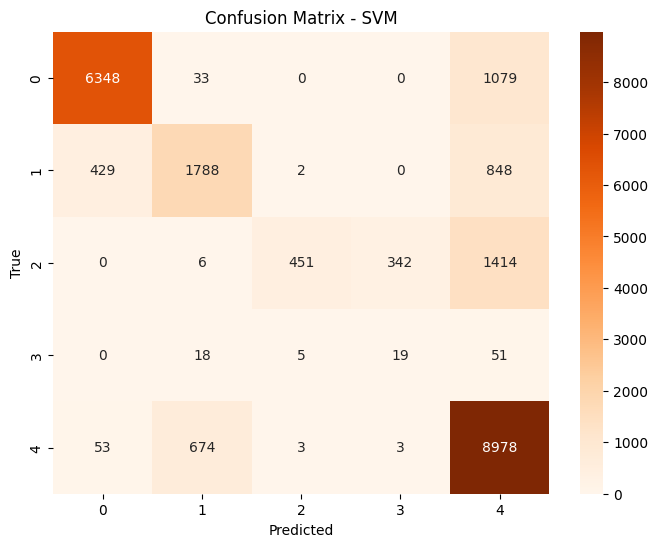

In [20]:
svm = SVC(random_state=42)
svm.fit(X_train_pt, y_train_smote)

y_pred_svm = svm.predict(X_test_pt)

print("Support Vector Machine Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_svm, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_svm, average='weighted'):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_svm, average='weighted'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Oranges')
plt.title('Confusion Matrix - SVM')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()